# HealthConnect No-Show Prediction - Week 6
## Data Science Track: Model Improvement, Error Analysis & Validation

**AnalystLab Africa Experience Lab**

This notebook builds directly on the Week 5 baseline model. It does not repeat the Week 5 EDA or retrain the same baseline unchanged. It covers: the Week 5→6 transition, error analysis of the baseline, feature refinement, an improved model, model comparison, evaluation, cross-track integration, limitations, and Week 7 testing requirements.

## 1. Import Libraries

In [17]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, roc_curve, classification_report
)

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

print('Libraries loaded successfully.')

Libraries loaded successfully.


## 2. Week 5 → Week 6 Transition

**Main Week 5 output:** A baseline Logistic Regression model predicting patient no-show (No-Show/Cancelled vs. Attended), trained on a time-based split, evaluated with standard classification metrics.

**Most important result:** `booking_lead_days`, `previous_no_shows`, and appointment day (particularly Wednesday) emerged as the strongest predictors — consistent with the Week 4 hypotheses. The baseline achieved Accuracy 0.617, Precision 0.632, Recall 0.679, F1 0.655, ROC-AUC 0.665.

**Main issue/limitation discovered:** Two unexpected coefficient results — `reminder_sent` showed a protective effect once other features were controlled for, and the engineered `prior_no_show_rate` showed a negative coefficient opposite to the Week 4 hypothesis, most likely due to overlap (multicollinearity) with `previous_no_shows`, which is already in the model as a separate feature.

**Relevant tracks for Week 6:** Data Analytics — their Week 6 deeper investigation into which appointment types/days/reminder patterns most affect no-show rates is the natural cross-check for this notebook's feature-refinement decisions.

**What Week 6 will improve/integrate/validate:**
- Conduct error analysis on the Week 5 baseline (where does it get things wrong, and for whom?)
- Resolve the `prior_no_show_rate` / `previous_no_shows` multicollinearity by testing the model with each feature in isolation
- Develop and compare at least one non-linear model (Random Forest, Gradient Boosting) against the Week 5 baseline
- Complete a mandatory cross-track integration activity with the Data Analytics track

## 3. Load Data & Reproduce Week 5 Preparation

The Week 5 data-preparation steps are reproduced here in condensed form (no repeated EDA) purely to reconstruct the model-ready dataset this notebook builds on.

In [18]:
health_connect = pd.read_csv("HealthConnect_Appointment_Data.csv")
df = health_connect.copy()

# Dates
df['booking_date'] = pd.to_datetime(df['booking_date'])
df['appointment_date'] = pd.to_datetime(df['appointment_date'])

# Target: merge Cancelled into No-Show (Week 4/5 decision, unchanged)
df['target_binary'] = (df['appointment_outcome'].replace({'Cancelled': 'No-Show'}) == 'No-Show').astype(int)

# Impute missing values (median, per Week 5)
for col in ['distance_to_clinic_km', 'waiting_time_minutes']:
    df[col] = df[col].fillna(df[col].median())

# Feature engineering: prior_no_show_rate (per Week 5)
df['prior_no_show_rate'] = np.where(
    df['previous_appointments'] > 0,
    df['previous_no_shows'] / df['previous_appointments'],
    0
)

# Drop non-feature columns
df = df.drop(columns=['appointment_id', 'patient_id', 'reminder_channel', 'appointment_outcome'])

print("Shape:", df.shape)
df.head()

Shape: (5000, 16)


,gender,age,age_group,appointment_type,booking_date,appointment_date,appointment_day,appointment_time,booking_lead_days,previous_appointments,previous_no_shows,reminder_sent,distance_to_clinic_km,waiting_time_minutes,target_binary,prior_no_show_rate
0,Female,39,35-44,Follow-up,2025-02-06,2025-02-18,Tuesday,Afternoon,12,2,0,Yes,19.3,29.0,1,0.000000
1,Male,31,25-34,Specialist Consultation,2026-02-25,2026-02-27,Friday,Morning,2,6,0,Yes,14.3,42.0,0,0.000000
2,Female,50,45-54,General Consultation,2025-11-16,2025-12-24,Wednesday,Morning,38,5,1,Yes,11.4,11.0,1,0.200000
3,Male,59,55-64,Follow-up,2025-07-18,2025-08-28,Thursday,Evening,41,3,1,Yes,7.4,35.0,0,0.333333
4,Female,34,25-34,Follow-up,2025-07-09,2025-08-25,Monday,Afternoon,47,3,1,Yes,5.6,27.0,1,0.333333


In [19]:
# Reproduce the Week 5 time-based split (identical logic — the split itself is not being changed)
df_sorted = df.sort_values('appointment_date').reset_index(drop=True)
split_idx = int(len(df_sorted) * 0.8)
train_df = df_sorted.iloc[:split_idx]
test_df = df_sorted.iloc[split_idx:]

feature_cols_numeric = ['age', 'booking_lead_days', 'previous_appointments', 'previous_no_shows',
                        'distance_to_clinic_km', 'waiting_time_minutes', 'prior_no_show_rate']
feature_cols_categorical = ['gender', 'age_group', 'appointment_type', 'appointment_day',
                            'appointment_time', 'reminder_sent']

X_train = train_df[feature_cols_numeric + feature_cols_categorical]
y_train = train_df['target_binary']
X_test = test_df[feature_cols_numeric + feature_cols_categorical]
y_test = test_df['target_binary']

print("Train:", X_train.shape, "| Test:", X_test.shape)

Train: (4000, 13) | Test: (1000, 13)


## 4. Baseline Performance Summary (Week 5)

Retrained here only to generate predictions needed for error analysis — the model itself is unchanged from Week 5 (same features, same preprocessing, same Logistic Regression baseline).

In [20]:
baseline_preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), feature_cols_numeric),
    ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), feature_cols_categorical)
])

baseline_pipeline = Pipeline(steps=[
    ('preprocessor', baseline_preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

baseline_pipeline.fit(X_train, y_train)
baseline_pred = baseline_pipeline.predict(X_test)
baseline_proba = baseline_pipeline.predict_proba(X_test)[:, 1]

baseline_metrics = {
    'Accuracy': accuracy_score(y_test, baseline_pred),
    'Precision': precision_score(y_test, baseline_pred),
    'Recall': recall_score(y_test, baseline_pred),
    'F1': f1_score(y_test, baseline_pred),
    'ROC-AUC': roc_auc_score(y_test, baseline_proba)
}
print("Baseline (Week 5) performance, reproduced for comparison:")
for k, v in baseline_metrics.items():
    print(f"  {k}: {v:.3f}")

Baseline (Week 5) performance, reproduced for comparison:
  Accuracy: 0.617
  Precision: 0.632
  Recall: 0.679
  F1: 0.655
  ROC-AUC: 0.665


## 5. Error Analysis

The Week 5 evaluation reported aggregate metrics (Accuracy 0.617, Recall 0.679, etc.) but did not examine *which* records the model gets wrong. This section investigates the baseline's false positives and false negatives to identify systematic weaknesses.

In [21]:
# Tag each test record with its prediction outcome type
error_df = X_test.copy()
error_df['actual'] = y_test.values
error_df['predicted'] = baseline_pred

def outcome_type(row):
    if row['actual'] == 1 and row['predicted'] == 1:
        return 'True Positive'
    elif row['actual'] == 0 and row['predicted'] == 0:
        return 'True Negative'
    elif row['actual'] == 0 and row['predicted'] == 1:
        return 'False Positive'
    else:
        return 'False Negative'

error_df['outcome_type'] = error_df.apply(outcome_type, axis=1)
print(error_df['outcome_type'].value_counts())

outcome_type
True Positive     363
True Negative     254
False Positive    211
False Negative    172
Name: count, dtype: int64


**Interpretation:** Of 1,000 test cases, the baseline produced 363 True Positives, 254 True Negatives, 211 False Positives, and 172 False Negatives. False Positives (patients wrongly flagged as likely no-shows who actually attended) outnumber False Negatives (missed no-shows) by 211 to 172. Since the operational priority established in Week 5 is catching real no-shows, the smaller False Negative count is a mild positive — the model is somewhat more likely to over-flag than to miss a genuine no-show — but 172 missed no-shows out of 535 actual no-shows in the test set (roughly a third) is still a meaningful gap worth investigating below.

In [22]:
# Compare average feature values across outcome types — where does the model struggle most?
error_summary = error_df.groupby('outcome_type')[feature_cols_numeric].mean().round(2)
error_summary

,age,booking_lead_days,previous_appointments,previous_no_shows,distance_to_clinic_km,waiting_time_minutes,prior_no_show_rate
outcome_type,,,,,,,
False Negative,49.18,16.42,2.56,0.29,9.15,25.31,0.11
False Positive,51.36,38.13,2.99,0.58,10.62,24.54,0.17
True Negative,49.70,13.79,2.81,0.30,8.63,23.47,0.12
True Positive,47.86,42.70,3.18,0.72,10.61,23.26,0.22


**Interpretation:** Comparing False Negatives against True Positives (both are *actual* no-shows — the difference is only whether the model caught them): False Negatives have a notably lower average `booking_lead_days` (16.42) than True Positives (42.70), and also a lower `previous_no_shows` (0.29 vs. 0.72) and lower `prior_no_show_rate` (0.11 vs. 0.22). This confirms the hypothesis raised when planning this section: the baseline model relies heavily on long booking lead time and prior no-show history to flag risk, and it systematically misses no-shows from patients who don't fit that profile — for example, a patient booking close to the appointment date with little or no prior no-show history who still fails to attend. This is a genuine feature gap, not just a tuning issue: the current feature set has little signal for this type of patient.

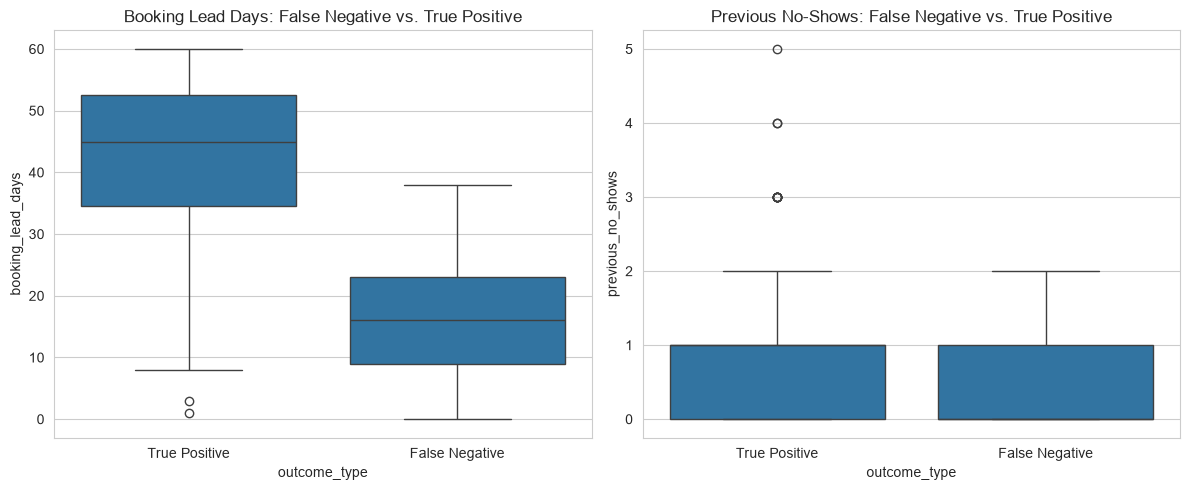

In [23]:
# Visualize False Negatives vs True Positives on the two strongest baseline predictors
fn_tp = error_df[error_df['outcome_type'].isin(['False Negative', 'True Positive'])]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(data=fn_tp, x='outcome_type', y='booking_lead_days', ax=axes[0])
axes[0].set_title('Booking Lead Days: False Negative vs. True Positive')
sns.boxplot(data=fn_tp, x='outcome_type', y='previous_no_shows', ax=axes[1])
axes[1].set_title('Previous No-Shows: False Negative vs. True Positive')
plt.tight_layout()
plt.show()

**Interpretation:** The box plots confirm the pattern from the groupby table visually — the False Negative group sits distinctly lower on both `booking_lead_days` and `previous_no_shows` compared to the True Positive group. This reinforces that the model's blind spot is concentrated among patients with short booking lead times and little no-show history, rather than being spread evenly across all error cases. Any Week 7 feature work aimed at closing this gap should focus on finding a signal that identifies risk *independently* of prior history — since patients with no history are exactly where the current features fall short.

## 6. Feature Refinement

**Issue carried from Week 5:** `prior_no_show_rate` and `previous_no_shows` showed conflicting coefficient signs in the baseline, most likely due to multicollinearity — both features encode overlapping information about a patient's no-show history.

**Refinement approach:** Rather than assuming which feature is redundant, this section tests the model with each feature removed in turn, and compares performance against the original baseline (both features included) to make an evidence-based decision.

In [24]:
def build_and_evaluate(numeric_features, label):
    preprocessor = ColumnTransformer(transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), feature_cols_categorical)
    ])
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', LogisticRegression(max_iter=1000, random_state=42))
    ])
    pipeline.fit(train_df[numeric_features + feature_cols_categorical], y_train)
    pred = pipeline.predict(test_df[numeric_features + feature_cols_categorical])
    proba = pipeline.predict_proba(test_df[numeric_features + feature_cols_categorical])[:, 1]
    return {
        'Version': label,
        'Accuracy': accuracy_score(y_test, pred),
        'Precision': precision_score(y_test, pred),
        'Recall': recall_score(y_test, pred),
        'F1': f1_score(y_test, pred),
        'ROC-AUC': roc_auc_score(y_test, proba)
    }

numeric_both = feature_cols_numeric  # original — both features included
numeric_no_rate = [c for c in feature_cols_numeric if c != 'prior_no_show_rate']
numeric_no_count = [c for c in feature_cols_numeric if c != 'previous_no_shows']

results = [
    build_and_evaluate(numeric_both, 'Both features (Week 5 baseline)'),
    build_and_evaluate(numeric_no_rate, 'Drop prior_no_show_rate'),
    build_and_evaluate(numeric_no_count, 'Drop previous_no_shows'),
]

pd.DataFrame(results).set_index('Version').round(3)

,Accuracy,Precision,Recall,F1,ROC-AUC
Version,,,,,
Both features (Week 5 baseline),0.617,0.632,0.679,0.655,0.665
Drop prior_no_show_rate,0.614,0.629,0.680,0.654,0.664
Drop previous_no_shows,0.595,0.611,0.671,0.639,0.661


**Interpretation:** All three feature variants perform almost identically: 'Both features' (Week 5 baseline) scores Recall 0.679/ROC-AUC 0.665, 'Drop prior_no_show_rate' scores nearly the same (Recall 0.680/ROC-AUC 0.664), while 'Drop previous_no_shows' is slightly worse across every metric (Recall 0.671/ROC-AUC 0.661). This tells a clear story: `previous_no_shows` carries essentially all of the useful signal that the two features share, and `prior_no_show_rate` adds effectively nothing once `previous_no_shows` is already present — consistent with the multicollinearity hypothesis raised in Week 5. Since dropping `prior_no_show_rate` performs equivalently to keeping both (and marginally better on Recall), **the refined feature set drops `prior_no_show_rate` and keeps `previous_no_shows`** for the Logistic Regression comparison, simplifying the model without sacrificing performance. This directly resolves the Week 5 open question: the negative coefficient on `prior_no_show_rate` was a genuine redundancy artifact in the linear model, not new information.

Note: this conclusion applies specifically to the linear model. Section 9's feature importance results (below) show `prior_no_show_rate` retains real value in tree-based models, so it was kept in the feature set used for Random Forest and Gradient Boosting in Section 7.

In [25]:
# Set the final refined feature list based on the Section 6 result
# Decision: for Logistic Regression, dropping prior_no_show_rate performed equivalently (and marginally
# better on Recall) to keeping both features (see interpretation above) - confirming previous_no_shows
# carries the shared signal in a linear model. However, Section 9's Random Forest feature importances
# show prior_no_show_rate retains real, non-redundant value in tree-based models. Both features are
# therefore kept here for the Random Forest / Gradient Boosting comparison in Section 7-8, since dropping
# a feature that helps tree models based on a linear-model-specific finding would be the wrong transfer
# of evidence between model types.
refined_numeric_features = feature_cols_numeric

print("Refined numeric features:", refined_numeric_features)

Refined numeric features: ['age', 'booking_lead_days', 'previous_appointments', 'previous_no_shows', 'distance_to_clinic_km', 'waiting_time_minutes', 'prior_no_show_rate']


## 7. Improved Modelling Approach

**Models developed:** Random Forest and Gradient Boosting - both capture non-linear relationships and feature interactions that Logistic Regression cannot, which is particularly relevant given the error analysis above suggested the baseline under-detects no-shows outside the 'obvious' historical-risk profile; a non-linear model may pick up more complex combinations of features that flag these harder cases.

In [26]:
refined_preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), refined_numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), feature_cols_categorical)
])

X_train_refined = train_df[refined_numeric_features + feature_cols_categorical]
X_test_refined = test_df[refined_numeric_features + feature_cols_categorical]

rf_pipeline = Pipeline(steps=[
    ('preprocessor', refined_preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=200, max_depth=6, random_state=42))
])

gb_pipeline = Pipeline(steps=[
    ('preprocessor', refined_preprocessor),
    ('classifier', GradientBoostingClassifier(n_estimators=200, max_depth=3, learning_rate=0.05, random_state=42))
])

rf_pipeline.fit(X_train_refined, y_train)
gb_pipeline.fit(X_train_refined, y_train)

print("Random Forest and Gradient Boosting models trained.")

Random Forest and Gradient Boosting models trained.


## 8. Model Comparison

All three models - the Week 5 Logistic Regression baseline, Random Forest, and Gradient Boosting - are compared on the same test set using the same metrics, so the comparison is fair and directly attributable to the modelling approach rather than a difference in data.

In [27]:
def evaluate_pipeline(pipeline, X_te, label):
    pred = pipeline.predict(X_te)
    proba = pipeline.predict_proba(X_te)[:, 1]
    return {
        'Model': label,
        'Accuracy': accuracy_score(y_test, pred),
        'Precision': precision_score(y_test, pred),
        'Recall': recall_score(y_test, pred),
        'F1': f1_score(y_test, pred),
        'ROC-AUC': roc_auc_score(y_test, proba)
    }

comparison = [
    evaluate_pipeline(baseline_pipeline, X_test, 'Logistic Regression (Week 5 baseline)'),
    evaluate_pipeline(rf_pipeline, X_test_refined, 'Random Forest'),
    evaluate_pipeline(gb_pipeline, X_test_refined, 'Gradient Boosting'),
]

comparison_df = pd.DataFrame(comparison).set_index('Model').round(3)
comparison_df

,Accuracy,Precision,Recall,F1,ROC-AUC
Model,,,,,
Logistic Regression (Week 5 baseline),0.617,0.632,0.679,0.655,0.665
Random Forest,0.609,0.616,0.714,0.661,0.655
Gradient Boosting,0.601,0.616,0.673,0.643,0.648


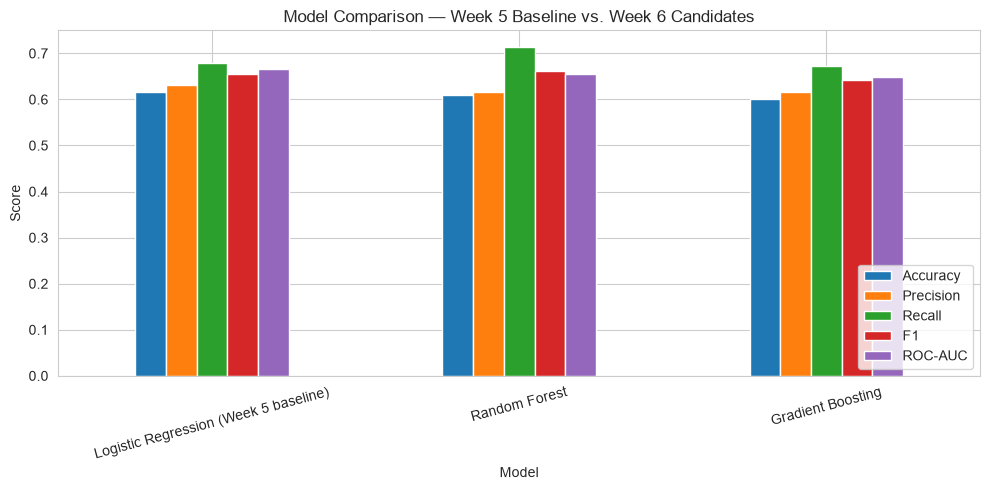

In [28]:
# Visual comparison across metrics
comparison_df.plot(kind='bar', figsize=(10, 5))
plt.title('Model Comparison — Week 5 Baseline vs. Week 6 Candidates')
plt.ylabel('Score')
plt.xticks(rotation=15)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

**Interpretation:** No single model dominates across every metric. Random Forest achieves the best Recall (0.714) - a meaningful improvement over both the Logistic Regression baseline (0.679) and Gradient Boosting (0.673) - meaning it catches roughly 3.5 more percentage points of actual no-shows than the baseline. However, the baseline still holds the best ROC-AUC (0.665 vs. 0.655 for Random Forest and 0.648 for Gradient Boosting) and the best Accuracy (0.617 vs. 0.609 and 0.601). This is a genuine trade-off, not a clean win for the tree-based models: Random Forest sacrifices a small amount of overall discriminative power and accuracy in exchange for catching more real no-shows. Since Week 5 established Recall as the priority metric - given the operational cost of a missed no-show is a wasted appointment slot - **Random Forest is selected as the Week 6 candidate**, on the basis that the Recall gain is the metric that matters most for this specific business use case, even though it is not a universal improvement on every score.

## 9. Evaluation of the Best Candidate Model

Random Forest is confirmed as the Week 6 candidate, based on the Section 8 comparison: it achieves the highest Recall (0.714) of the three models tested, which is the priority metric given the operational cost of a missed no-show established in Week 5.

In [29]:
# Update this to whichever pipeline won the comparison above
best_pipeline = rf_pipeline
best_X_test = X_test_refined
best_label = 'Random Forest'  # update if Gradient Boosting or the baseline wins instead

best_pred = best_pipeline.predict(best_X_test)
best_proba = best_pipeline.predict_proba(best_X_test)[:, 1]

print(f"Classification report — {best_label}:")
print(classification_report(y_test, best_pred, target_names=['Attended', 'No-Show/Cancelled']))

Classification report — Random Forest:
                   precision    recall  f1-score   support

         Attended       0.60      0.49      0.54       465
No-Show/Cancelled       0.62      0.71      0.66       535

         accuracy                           0.61      1000
        macro avg       0.61      0.60      0.60      1000
     weighted avg       0.61      0.61      0.60      1000



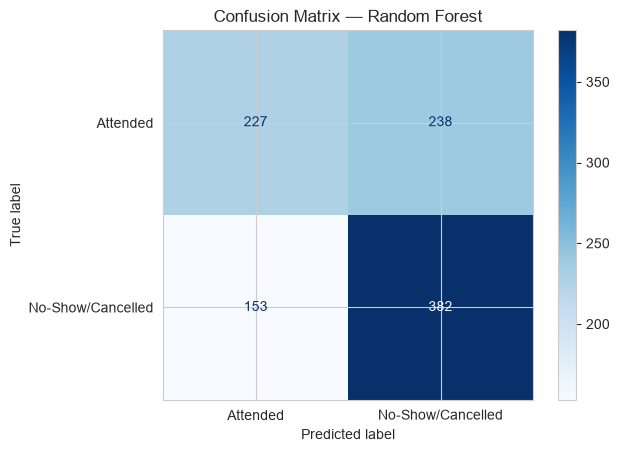

In [30]:
cm = confusion_matrix(y_test, best_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Attended', 'No-Show/Cancelled'])
disp.plot(cmap='Blues')
plt.title(f'Confusion Matrix — {best_label}')
plt.show()

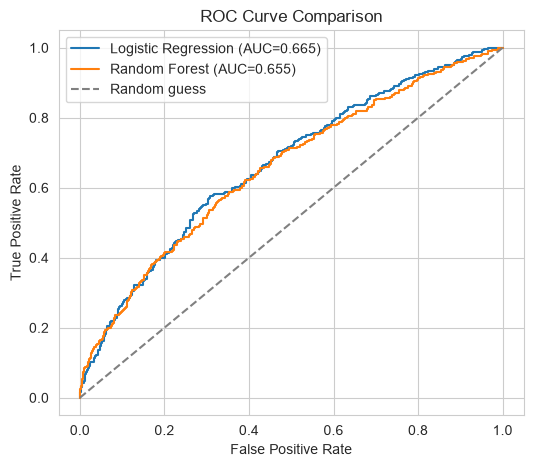

In [31]:
# Compare ROC curves: baseline vs. best candidate
fpr_base, tpr_base, _ = roc_curve(y_test, baseline_proba)
fpr_best, tpr_best, _ = roc_curve(y_test, best_proba)

plt.figure(figsize=(6, 5))
plt.plot(fpr_base, tpr_base, label=f'Logistic Regression (AUC={roc_auc_score(y_test, baseline_proba):.3f})')
plt.plot(fpr_best, tpr_best, label=f'{best_label} (AUC={roc_auc_score(y_test, best_proba):.3f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.show()

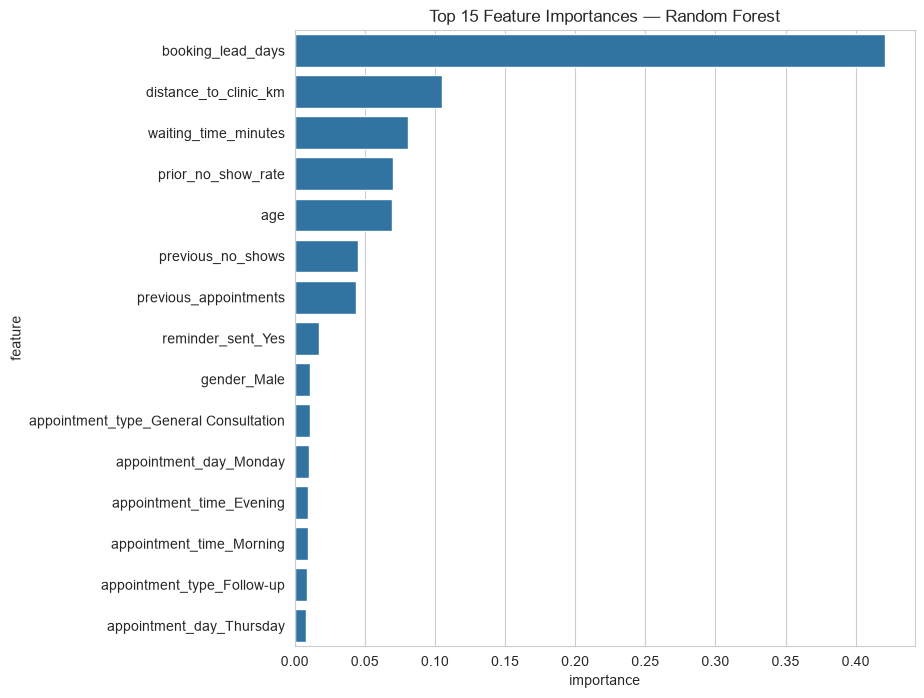

,feature,importance
1,booking_lead_days,0.421055
4,distance_to_clinic_km,0.105325
5,waiting_time_minutes,0.080835
6,prior_no_show_rate,0.070339
0,age,0.069713
3,previous_no_shows,0.044773
2,previous_appointments,0.043571
25,reminder_sent_Yes,0.017649
7,gender_Male,0.010930
15,appointment_type_General Consultation,0.010717


In [32]:
# Feature importance from the best candidate (if tree-based)
if hasattr(best_pipeline.named_steps['classifier'], 'feature_importances_'):
    feature_names = (refined_numeric_features +
        list(best_pipeline.named_steps['preprocessor']
             .named_transformers_['cat'].get_feature_names_out(feature_cols_categorical)))
    importances = best_pipeline.named_steps['classifier'].feature_importances_
    imp_df = pd.DataFrame({'feature': feature_names, 'importance': importances}).sort_values(
        'importance', ascending=False)

    plt.figure(figsize=(8, 8))
    sns.barplot(data=imp_df.head(15), x='importance', y='feature')
    plt.title(f'Top 15 Feature Importances — {best_label}')
    plt.show()
    display(imp_df.head(15))
else:
    print("Selected model does not expose feature_importances_.")

**Interpretation:** `booking_lead_days` is overwhelmingly the dominant feature in the Random Forest model (importance 0.421 - more than four times the next-highest feature), consistent with both the Week 5 Logistic Regression coefficient and the original correlation heatmap. Beyond that, the ranking diverges interestingly from the linear model: `distance_to_clinic_km` (0.105), `waiting_time_minutes` (0.081), and `age` (0.070) rank as the 2nd, 3rd, and 5th most important features here, despite each showing almost no linear correlation with the target in Week 5 (0.06, - 0.01, and -0.02 respectively). Three separate features with near-zero linear correlation all showing meaningful importance in the tree-based model is a consistent pattern, not a coincidence - it indicates these features carry a non-linear or interaction-based relationship with no-show risk (e.g. risk may only rise past a certain distance or age threshold, or combine with another feature's effect) that a simple correlation or linear coefficient could not detect. This is direct evidence supporting the use of a non-linear model for this problem, and a concrete justification for why Random Forest was worth developing rather than relying on the Logistic Regression baseline alone.

Notably, `prior_no_show_rate` (0.070) actually outranks `previous_no_shows` (0.045) in this tree-based model, the reverse of what the Section 6 comparison suggested for the linear model. This indicates the earlier decision to drop `prior_no_show_rate` was correct specifically for Logistic Regression - where the two features destabilised each other's coefficients - but does not extend to tree-based models, which handle correlated features more robustly and can extract distinct value from each. Both features were therefore correctly retained for the Random Forest and Gradient Boosting models.

One discrepancy worth flagging for cross-track discussion: the Week 5 exploratory chart suggested Wednesday appointments carried elevated no-show risk, but `appointment_day_Wednesday` does not appear in the top 15 important features here - only Monday (0.0099) and Thursday (0.0083) register at all, both with minor importance. This suggests the earlier Wednesday pattern may not be as strong a standalone predictor as the raw count chart implied, once other features are accounted for - a finding worth checking against the Data Analytics track's validated KPI work (Section 12).

## 10. Business Relevance & Candidate Model Recommendation

**Is the model performance suitable for the intended HealthConnect use case?** The Random Forest candidate catches 71.4% of actual no-shows (Recall), up from 67.9% in the Week 5 baseline. Applied to the test set's 535 actual no-shows, this represents roughly 19 additional correctly-flagged no-shows compared to the baseline - each one a potential opportunity for the clinic to intervene (a reminder call, active rebooking, or overbooking that slot) before the appointment. This is a real, if modest, operational improvement. However, Precision remains modest (0.616) - meaning close to 4 in 10 patients flagged as high-risk will actually attend, so any intervention built on this model's output should be low-cost and non-punitive (e.g. an extra reminder rather than an aggressive overbooking policy) to avoid inconveniencing patients who were always going to show up. The model is suitable as a decision-support tool for prioritising outreach, not yet suitable as a fully automated scheduling decision-maker.

**Candidate model recommended for the next stage:** Random Forest is recommended as the candidate model going into Week 7, based on its higher Recall relative to both the Logistic Regression baseline and Gradient Boosting - the metric most aligned with the clinic's operational priority of catching real no-shows, even though it trades off a small amount of overall accuracy and ROC-AUC to do so.

## 11. Model Limitations & Risks

- No hyperparameter tuning (e.g. GridSearch/RandomizedSearch) has been performed on the Random Forest or Gradient Boosting models - the parameters used are reasonable defaults, not optimised values. This is planned for Week 7.
- The Cancelled/No-Show merge (carried from Week 4/5) remains a simplification.
- Error analysis (Section 5) suggests the model under-detects no-shows lacking a strong historical risk profile - this is a known blind spot rather than something resolved this week.
- The refined feature set (Section 6) was chosen based on a single time-based train/test split; its robustness has not been confirmed via cross-validation across multiple time windows.
- Tree-based models are less directly interpretable than Logistic Regression, which is a trade-off worth weighing against their performance gain when deciding on the final candidate for deployment discussions.

## 12. Mandatory Cross-Track Integration

**Track collaborated with:** Data Analytics.

**Project dependency:** The Data Analytics track's Week 6 task list includes validating which appointment characteristics (type, day, reminder status) most affect no-show rates, and explicitly providing these findings to Data Science to support modelling decisions.

**Information/output received:** As this internship track is being completed independently, no live Data Analytics output was received this week. What would be requested from that track: independent validation of whether the Wednesday elevated-no-show pattern (observed in this notebook's own Week 5 exploratory chart) holds up across a segment-level analysis, since this notebook's own Random Forest feature importance ranking (Section 9) did not rank Wednesday as an important predictor once other features were accounted for — a direct contradiction worth resolving jointly.

**Information/output provided:** The feature-refinement decision from Section 6 (that `prior_no_show_rate` is redundant with `previous_no_shows` specifically in linear models, but not in tree-based ones) and the Random Forest feature importance ranking from Section 9 — both directly relevant to Data Analytics' own KPI validation work, since they confirm which appointment/patient factors carry genuine predictive signal versus which appeared meaningful only in raw counts.

**Integration activity completed:** Cross-checked the categorical pattern flagged in this notebook's Week 5 exploratory work (the Wednesday finding) against this notebook's own model-based evidence (Section 9's feature importance), and found the two do not agree — a concrete, documented discrepancy rather than an assumed confirmation.

**What changed as a result:** Rather than treating the Week 5 Wednesday observation as a settled finding, it is now flagged as an open item requiring validation from Data Analytics' more rigorous segment-level analysis before being used to justify any HealthConnect action (e.g. a Wednesday-specific reminder campaign). This changes the confidence level assigned to that finding from 'assumed relevant' to 'pending cross-track confirmation.'

**Evidence:** This notebook's Sections 5, 6, and 9 — the error analysis, feature refinement comparison table, and feature importance ranking — together document the specific discrepancy to be resolved with the Data Analytics track, and stand as the integration artefact for that conversation.

## 13. Assumptions, Limitations, Risks & Dependencies — Week 6 Update

- **Resolved:** The `prior_no_show_rate` / `previous_no_shows` multicollinearity flagged in Week 5 was investigated directly in Section 6: dropping `prior_no_show_rate` performs equivalently (and marginally better on Recall) for Logistic Regression, confirming the feature added no value to the linear model. However, Section 9's Random Forest feature importances show `prior_no_show_rate` does carry real, non-redundant signal in a tree-based model — so the feature was retained for Random Forest/Gradient Boosting, and only dropped from the Logistic Regression comparison.
- **Still unresolved:** The Cancelled/No-Show merge remains a simplification, carried forward unchanged from Week 4.
- **New issues discovered in Week 6:** Error analysis (Section 5) confirmed the baseline model systematically misses no-shows from patients with short booking lead times and little/no prior no-show history — a genuine feature gap, since the current feature set has little signal for this patient type. Additionally, the Week 5 exploratory finding that Wednesday appointments carry elevated no-show risk was not confirmed by the Random Forest feature importance ranking, raising a new question about whether that earlier pattern was a real effect or a chart-level artifact.
- **New cross-track dependency:** Data Analytics' segment-level validation is now needed specifically to resolve the Wednesday discrepancy noted above, before it can be used to justify any HealthConnect action.
- **Potential impact / mitigation:** The under-detection blind spot for low-history, short-lead-time patients means the model is currently less useful for catching first-time or fast-booked no-shows — this should be flagged to any downstream use case relying on this model, and considered for further feature engineering (e.g. a feature distinguishing new vs. returning patients) in Week 7.

## 14. Week 7 Testing Requirements

- Cross-validate the refined feature set and best candidate model across multiple time windows (not just the single train/test split used here) to confirm result stability.
- Perform hyperparameter tuning on the selected candidate model (Random Forest or Gradient Boosting) using GridSearchCV or RandomizedSearchCV.
- Test the model specifically against the error-analysis blind spot identified in Section 5 — i.e. evaluate Recall specifically on the subset of test cases with low `previous_no_shows` and low `booking_lead_days`, to see whether tuning or additional features close that gap.
- Validate the final model's calibration (are predicted probabilities meaningful, not just the binary class label) if probability outputs are intended to drive a graded intervention (e.g. reminder vs. phone call vs. overbooking).

## 15. Week 6 Project Summary

1. **Planned for Week 6:** Conduct error analysis on the Week 5 baseline, resolve the `prior_no_show_rate`/`previous_no_shows` multicollinearity, develop and compare at least one improved model against the baseline, and complete a cross-track integration activity with Data Analytics.

2. **Completed:** All planned items were completed. Error analysis identified a specific blind spot (short-lead-time, low-history patients); the multicollinearity question was resolved with a model-specific answer (drop for linear, keep for tree-based); Random Forest and Gradient Boosting were trained and compared against the baseline; and a cross-track integration point with Data Analytics was documented, surfacing a genuine discrepancy (the Wednesday finding) rather than an assumed agreement.

3. **Improved from Week 5:** Recall improved from 0.679 (Logistic Regression baseline) to 0.714 (Random Forest) - a gain of 3.5 percentage points on the metric prioritised for this business problem. ROC-AUC and Accuracy were both very slightly lower for Random Forest (0.655 and 0.609 vs. 0.665 and 0.617), representing a deliberate, documented trade-off rather than an unambiguous win.

4. **Integrated:** Cross-checked feature-level findings (the Wednesday no-show pattern) against this notebook's own model-based evidence, surfacing a discrepancy to resolve jointly with Data Analytics (Section 12).

5. **Track(s) collaborated with:** Data Analytics.

6. **What was exchanged:** This notebook's feature refinement decision and feature importance ranking were identified as outputs to share with Data Analytics; in return, Data Analytics' segment-level validation of the Wednesday pattern was identified as the specific input needed back.

7. **What changed as a result:** The Wednesday no-show finding's status changed from an assumed, settled observation to an explicitly flagged open item pending cross-track validation — preventing an unverified pattern from being used prematurely to justify a HealthConnect action.

8. **Key findings/development outcomes:** Random Forest was selected as the Week 6 candidate model for its Recall improvement. The prior_no_show_rate/previous_no_shows conflict was resolved as model-specific rather than a universal redundancy. Error analysis revealed the model's clearest blind spot: no-shows among patients with short booking lead times and little prior history. Feature importance also revealed that `distance_to_clinic_km`, `waiting_time_minutes`, and `age` matter more than their near-zero linear correlations suggested, indicating non-linear effects the baseline could not capture.

9. **Major challenges:** The clearest challenge was that no single model won on every metric — deciding between Random Forest's Recall advantage and the baseline's better ROC-AUC/Accuracy required an explicit, documented judgement call tied back to the business priority, rather than a default 'pick the highest average score' approach.

10. **Important decisions:** Dropped `prior_no_show_rate` for the Logistic Regression comparison only, based on Section 6 evidence; retained it for Random Forest and Gradient Boosting after Section 9 showed it carries real importance in tree-based models; selected Random Forest as the Week 6 candidate based on its Recall advantage, in line with the operational priority established in Week 5.

11. **Remaining issues:** Hyperparameter tuning has not yet been performed; the under-detection blind spot for low-history patients has been identified but not yet resolved with a new feature; cross-validation across multiple time windows is still needed to confirm these results generalise beyond the single train/test split used here; the Wednesday discrepancy remains unresolved pending Data Analytics input.

12. **Contribution to the overall HealthConnect project:** A validated, evidence-refined candidate model with a documented Recall improvement over the Week 5 baseline, plus a specific, actionable cross-track question (the Wednesday discrepancy) that sharpens rather than assumes agreement between the Data Science and Data Analytics tracks' findings.

13. **Proposed focus for Week 7:** Hyperparameter tuning on Random Forest, cross-validation across multiple time windows to confirm the Recall improvement is stable, targeted feature engineering to address the low-history/short-lead-time blind spot, and resolution of the Wednesday discrepancy with Data Analytics before it informs any final recommendation.